# 5章 IPパケットとフラグメント

前章まで、ローカルネットワークについて取り扱ってきました。
それに対して、今回はインターネットのような大きなネットワークにフォーカスします。
これらを繋ぐ考え方については、もう少し後で（部品が出揃ってから）作りながら学んでいきますので、まずは「前回までと違って、大きなネットワークをイメージしておけば良い」という点だけご留意ください。

## インターネットとIP

### インターネット

インターネットとは、コンピュータネットワークの中で最大のものです。
世界中のコンピュータネットワークが互いに接続された巨大なネットワークです。
ネットワークのネットワークとも言われ、ローカルネットワーク同士をどんどん接続していったものだとも言えます。
インターネットは非常に大きなネットワークですが、基本的な機能はここまでに学んできたネットワークとあまり変わらず、「データ（パケット）を目的地へと転送すること」です。
この転送は、インターネットプロトコル（IP）と呼ばれる標準的な方法を使用して行われます。

### IPパケット

IPパケットは、インターネットを介して送信されるデータの基本単位です。
私たちが普段使っているスマートフォンやPCなどで送受信されているデータも、IPパケットとして転送されているのです。
あらゆる種類のデータ（テキスト、画像、ビデオなど）は、IPパケットに分割され、送信された後、受信側で再び組み立てられます。
IPパケットは、効率的なデータ転送と、異なるネットワーク間での通信を可能にするために設計されています。

各IPパケットには、「IPヘッダ」と呼ばれる部分が含まれています。
ここまでに`Packet`クラスのヘッダを作成してきましたが、IPヘッダはその中に含まれます。
IPヘッダは、パケットの送信元と宛先の情報（IPアドレス）、パケットのサイズ、転送中のパケットの生存期間（TTL）、およびその他の制御情報を含んでいます。
IPヘッダは、パケットが正しく送信され、適切な宛先に到達するために不可欠です。

### IPアドレス

IPアドレスは、インターネット上の各デバイスに割り当てられたユニークな識別子です。
IPアドレスは、インターネット上でデータを送受信するために必要で、ネットワーク上の特定のデバイスを特定します。
現在、IPv4とIPv6の2種類のIPアドレスが使用されています。
IPv4は32ビットのアドレスを使用し、限られたアドレス空間を提供します。
一方、IPv6は128ビットのアドレスを使用し、はるかに広大なアドレス空間を提供します。
ここが少し分かりにくいところですが、IPパケットで用いられるアドレスは、IPアドレスです。
前章まで出てきたMACアドレスはローカルネットワーク内できちんと使われているのですが、グローバルなネットワークの中ではIPアドレスを住所として用いる、ということです。
この辺りの関係性などについては、もう少し後で詳しく扱います。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

fatal: destination path 'network-simulator' already exists and is not an empty directory.


### `Packet`クラスのアップデート

さて、早速ですが、`Packet`クラスを拡張し、IPヘッダの情報を付与していきましょう。
まず簡単のため「IPヘッダ」というヘッダは作らず、従来からある「ヘッダ」の中に、まとめてIPヘッダ情報も書き込むことにします。
IPヘッダには実際には多くのフィールドがあるのですが、分かりにくいので重要なものをピックアップして実装していきます。

#### IPアドレス

まず必須なのがIPアドレスです。
先に記述した通りIPv4とv6という2つのバージョンが用いられますが、学習用にはv4の方が分かりやすいので、ここではv4を前提に説明します。
IPアドレスは、インターネット上の各デバイスを識別するための一意の番号です。
どのデバイスがどのデバイスにデータを送るかを特定するために使われるため、IPヘッダには送信元IPアドレスと宛先IPアドレスが書き込まれます。

IPv4アドレスは、ドット（`.`）で区切られた4つの数字で表されます。
例えば、「192.168.1.1」のようになります。
各数字は0から255までの値を取ることができます。
IPアドレスは、ネットワークそのものを表すネットワーク部分と、そのネットワーク内のデバイスを表すホスト部に分けられます。
どこまでがネットワークアドレスで、どこからがホストアドレスかを示すために、「サブネットマスク」と呼ばれるものが使用されます。
この考え方は、パケットの転送経路の決め方（ルーティング）にも大きく関わってくるため、後で詳しく扱います（＝ここでは、まだ実装しません）。

IPアドレスは、インターネット上で一意である必要があります。
もし重複があったら、パケットの正しい宛先が分からなくなってしまいます。
よって勝手に好きなアドレスを使って良いわけではなく、きちんと管理されており、こうしたアドレスをグローバルアドレスと呼びます。
その一方で、ローカルネットワーク内など限定で勝手に使ってよいアドレスが定められており、こうしたアドレスはプライベートアドレスと呼ばれます。

#### TTL

TTL（Time To Live）は、ネットワーク上でデータパケットが生存できる期間または「ホップ数」（ルータなどの中継機器を経由する回数）を指定する値です。
要するにパケットの寿命を表し、パケットがネットワーク上で無限に循環することを防ぐために使用されます。
パケットが生成される際、TTLには初期値（通常は64や128など）が設定されます。
パケットがルータなどを通過するたびに、TTL値は1ずつ減少し、0になった時点で破棄されます。

#### フラグメント

フラグメント（Fragmentation）とは、ネットワーク上で大きなデータパケットを小さな単位に分割するプロセスです。
これは、データパケットがネットワークの異なる部分で許容される最大サイズ（MTU：Maximum Transmission Unit）より大きい場合に発生します。
つまり、あまり大きなサイズのパケットを許容できないリンクも存在するので、あらかじめパケットを細かく刻んでおく、という意味です。
フラグメントされたパケット（分割されたパケット）には、元のデータパケットの識別情報、フラグメントの順序、および最後のフラグメントであるかどうかを示すフラグが含まれます。
パケットの最終的な宛先に到達すると、フラグメントは元のデータパケットに再組み立てられます。

### `Packet`クラスの実装

#### コンストラクタ (`__init__` メソッド)

このメソッドは、パケットオブジェクトを初期化します。

- `source_mac` (送信元MACアドレス): パケットを送信するデバイスのMACアドレス。
- `destination_mac` (宛先MACアドレス): パケットの宛先デバイスのMACアドレス。
- `source_ip` (送信元IPアドレス): パケットを送信するデバイスのIPアドレス。
- `destination_ip` (宛先IPアドレス): パケットの宛先デバイスのIPアドレス。
- `ttl` (Time To Live): パケットがネットワーク上で生存する時間。
- `fragment_flags`: パケットのフラグメントに関連する情報を含むフラグ。
- `fragment_offset`: パケットのどの部分がフラグメント化されたかを示すオフセット。
- `header_size`: パケットヘッダのサイズ。
- `payload_size`: パケットのペイロード（データ部分）のサイズ。
- `network_event_scheduler`: ネットワークイベントを管理するスケジューラ。

パケットは一意のID（`uuid.uuid4()`を使用して生成）が割り当てられ、ヘッダとペイロードのサイズに基づいて全体のサイズが計算されます。パケットの生成時刻と到着時刻も記録されます。

```
class Packet:
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, ttl, fragment_flags, fragment_offset, header_size, payload_size, network_event_scheduler):
        # コンストラクタ：パケットの初期化
        self.network_event_scheduler = network_event_scheduler  # ネットワークイベントスケジューラ
        self.id = str(uuid.uuid4())  # パケットに一意のIDを割り当てる
        # パケットヘッダの情報を設定
        self.header = {
            "source_mac": source_mac,  # 送信元MACアドレス
            "destination_mac": destination_mac,  # 宛先MACアドレス
            "source_ip": source_ip,  # 送信元IPアドレス
            "destination_ip": destination_ip,  # 宛先IPアドレス
            "ttl": ttl,  # パケットの生存時間（TTL）
            "fragment_flags": fragment_flags,  # フラグメント関連のフラグ
            "fragment_offset": fragment_offset  # フラグメントのオフセット
        }
        self.payload = b'X' * payload_size  # ペイロード（データ部分）を生成
        self.size = header_size + payload_size  # パケット全体のサイズ
        self.creation_time = self.network_event_scheduler.current_time  # パケット生成時刻
        self.arrival_time = None  # 到着時刻（初期値はNone）
```

#### メソッド

- `set_arrived(arrival_time)`: パケットが宛先に到着した時刻を記録するメソッド。
- `__lt__(other)`: パケットを比較するための特殊メソッド。
- `__str__()`: パケットの内容を文字列形式で表現する特殊メソッド。デバッグやログ出力に便利です。

```
    def set_arrived(self, arrival_time):
        # 到着時刻を設定するメソッド
        self.arrival_time = arrival_time

    def __lt__(self, other):
        # パケットの比較用メソッド（heapqなどで使用）
        return False  # デフォルトではFalseを返す

    def __str__(self):
        # パケットの文字列表現
        return f'パケット(送信元MAC: {self.header["source_mac"]}, 宛先MAC: {self.header["destination_mac"]}, 送信元IP: {self.header["source_ip"]}, 宛先IP: {self.header["destination_ip"]}, TTL: {self.header["ttl"]}, フラグメントフラグ: {self.header["fragment_flags"]}, フラグメントオフセット: {self.header["fragment_offset"]}, ペイロード: {self.payload})'
```


In [ ]:
import uuid  # uuidライブラリをインポート（ユニークなID生成用）

class Packet:
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, ttl, fragment_flags, fragment_offset, header_size, payload_size, network_event_scheduler):
        # コンストラクタ：パケットの初期化
        self.network_event_scheduler = network_event_scheduler  # ネットワークイベントスケジューラ
        self.id = str(uuid.uuid4())  # パケットに一意のIDを割り当てる
        # パケットヘッダの情報を設定
        self.header = {
            "source_mac": source_mac,  # 送信元MACアドレス
            "destination_mac": destination_mac,  # 宛先MACアドレス
            "source_ip": source_ip,  # 送信元IPアドレス
            "destination_ip": destination_ip,  # 宛先IPアドレス
            "ttl": ttl,  # パケットの生存時間（TTL）
            "fragment_flags": fragment_flags,  # フラグメント関連のフラグ
            "fragment_offset": fragment_offset  # フラグメントのオフセット
        }
        self.payload = b'X' * payload_size  # ペイロード（データ部分）を生成
        self.size = header_size + payload_size  # パケット全体のサイズ
        self.creation_time = self.network_event_scheduler.current_time  # パケット生成時刻
        self.arrival_time = None  # 到着時刻（初期値はNone）

    def set_arrived(self, arrival_time):
        # 到着時刻を設定するメソッド
        self.arrival_time = arrival_time

    def __lt__(self, other):
        # パケットの比較用メソッド（heapqなどで使用）
        return False  # デフォルトではFalseを返す

    def __str__(self):
        # パケットの文字列表現
        return f'パケット(送信元MAC: {self.header["source_mac"]}, 宛先MAC: {self.header["destination_mac"]}, 送信元IP: {self.header["source_ip"]}, 宛先IP: {self.header["destination_ip"]}, TTL: {self.header["ttl"]}, フラグメントフラグ: {self.header["fragment_flags"]}, フラグメントオフセット: {self.header["fragment_offset"]}, ペイロード: {self.payload})'


### `Node`クラスのアップデート

IPアドレスを用いてパケット送受信を行う点と、データサイズが大きい場合にフラグメントを行い、またフラグメントされたパケットを受信して組み立てられるように修正します。
主なポイントは以下です。

#### コンストラクタ (`__init__` メソッド)

各ノードは一意のIPアドレスを持ち、これによりネットワーク内で識別されます。IPアドレスは、ネットワーク上でのパケットのルーティングに重要な役割を果たします。

```
class Node:
    def __init__(self, node_id, mac_address, ip_address, network_event_scheduler, mtu=1500, default_route=None):
        # 各ノードの初期化。ノードID、MACアドレス、IPアドレス、イベントスケジューラを設定。
        # MTU（Maximum Transmission Unit）とデフォルトルートもオプションで設定可能。

        # MACアドレスが有効な形式かどうか確認
        if not self.is_valid_mac_address(mac_address):
            raise ValueError("無効なMACアドレス形式です。")

        # IPアドレスが有効な形式かどうか確認
        if not (self.is_valid_ipv4_address(ip_address)):
            raise ValueError("無効なIPアドレス形式です。")

        # インスタンス変数の設定
        self.network_event_scheduler = network_event_scheduler
        self.node_id = node_id
        self.mac_address = mac_address  # MACアドレス
        self.ip_address = ip_address  # IPアドレス
        self.links = []  # 接続されているリンク
        self.mtu = mtu  # MTUの設定。デフォルトは1500バイト。
        self.fragmented_packets = {}  # フラグメントされたパケットを一時的に格納するための辞書
        self.default_route = default_route  # デフォルトルート（なければNone）

        # ネットワークイベントスケジューラにノードを追加
        label = f'Node {node_id}\n{mac_address}'
        self.network_event_scheduler.add_node(node_id, label)
```

パケットサイズがMTUを超える場合、パケットはフラグメント化（分割）され、分割された各部分は`fragmented_packets`で一時的に保持されます。

```
self.mtu = mtu  # MTUの設定。デフォルトは1500バイト。これはネットワークを介して送信できる最大パケットサイズを指します。
self.fragmented_packets = {}  # フラグメントされたパケットを一時的に格納するための辞書
- `fragmented_packets`: フラグメントされたパケットを一時的に保持するための辞書。
```

#### IPアドレスのバリデーション

IPv4アドレスの形式が正しいかどうかを検証するメソッドです。

```
    # IPv4アドレスの有効性をチェックするメソッド
    def is_valid_ipv4_address(self, ip_address):
        """IPv4アドレスが有効な形式かどうかをチェックする関数"""
        ipv4_format = re.compile(r'^(\d{1,3}\.){3}\d{1,3}$')
        if ipv4_format.match(ip_address):
            return all(0 <= int(octet) <= 255 for octet in ip_address.split('.'))
        return False

    # IPv6アドレスの有効性をチェックするメソッド
    def is_valid_ipv6_address(self, ip_address):
        """IPv6アドレスが有効な形式かどうかをチェックする関数"""
        ipv6_format = re.compile(r'^([0-9a-fA-F]{1,4}:){7}[0-9a-fA-F]{1,4}$')
        return bool(ipv6_format.match(ip_address))
```

#### `receive_packet` メソッド

このメソッドは、ノードがパケットを受信した際に呼び出されます。

```
    # パケットを受信するメソッド
    def receive_packet(self, packet, received_link):
        if packet.arrival_time == -1:
            # パケットが失われた（到着時間が-1）場合、ロスとしてログに記録
            self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)
            return

        if packet.header["destination_mac"] == self.mac_address:
            # 宛先MACアドレスがこのノードのMACアドレスと一致する場合、さらにIPアドレスを確認
            if packet.header["destination_ip"] == self.ip_address:
                # 宛先IPがこのノードのIPアドレスと一致する場合、パケット到着をログに記録
                self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
                packet.set_arrived(self.network_event_scheduler.current_time)

                # フラグメントされたパケットの処理を行う
                # more_fragmentsフラグがTrueの場合は、パケットをストアし、
                # Falseの場合は、パケットを再組み立てする
                if packet.header["fragment_flags"]["more_fragments"]:
                    self._store_fragment(packet)
                else:
                    self._reassemble_and_process_packet(packet)
            else:
                # 宛先IPが異なる場合は特に何もしない（ここでの処理は省略）
                pass
```

宛先IPがノードのIPアドレスと一致する場合、パケット到着をログに記録し、パケットのフラグメント化に関連する処理を行います。
  - `more_fragments`フラグがTrueの場合は、パケットを一時的に保存します。
  - Falseの場合は、パケットを再組み立てし、処理を行います。

```
                # フラグメントされたパケットの処理を行う
                # more_fragmentsフラグがTrueの場合は、パケットをストアし、
                # Falseの場合は、パケットを再組み立てする
                if packet.header["fragment_flags"]["more_fragments"]:
                    self._store_fragment(packet)
                else:
                    self._reassemble_and_process_packet(packet)
```

#### `_store_fragment` メソッド

このメソッドは、フラグメント化されたパケットを一時的に保存するために使用されます。同一のオリジナルデータIDを持つフラグメントを同じ辞書に格納します。

```
    # フラグメントされたパケットを一時的に保存するメソッド
    def _store_fragment(self, fragment):
        original_data_id = fragment.header["fragment_flags"]["original_data_id"]
        offset = fragment.header["fragment_offset"]

        # 同一のオリジナルデータIDのフラグメントを同じ辞書に格納する
        if original_data_id not in self.fragmented_packets:
            self.fragmented_packets[original_data_id] = {}
        self.fragmented_packets[original_data_id][offset] = fragment

        # フラグメントの保存をログに記録
        self.network_event_scheduler.log_packet_info(fragment, "fragment_stored", self.node_id)
```

#### `_reassemble_and_process_packet` メソッド

このメソッドは、フラグメント化されたパケットを再組み立てし、処理するために使用されます。

- 対応するフラグメントがない場合、再組み立てに失敗したことをログに記録し、処理を終了します。
- フラグメントを取得し、オフセットに基づいてソートしてから再組み立てます。
- 完全に再組み立てされたデータをバイト列として結合し、再構築します。
- 期待されるデータの全長と実際の総データ長を比較し、欠けているフラグメントがある場合は再組み立てに失敗したことをログに記録します。

```
    # フラグメントされたパケットを再組み立てし、処理するメソッド
    def _reassemble_and_process_packet(self, last_fragment):
        original_data_id = last_fragment.header["fragment_flags"]["original_data_id"]
        if original_data_id not in self.fragmented_packets:
            # 対応するフラグメントがない場合、再組み立て失敗としてログに記録
            self.network_event_scheduler.log_packet_info(last_fragment, "reassemble_failed_no_fragments", self.node_id)
            return

        # フラグメントをオリジナルデータIDに基づいて取得し、ソート
        fragments = self.fragmented_packets.pop(original_data_id)
        sorted_offsets = sorted(fragments.keys())

        # 再組み立てされたデータを結合して再構築
        reassembled_data = b''.join(fragments[offset].payload for offset in sorted_offsets)

        # 期待される全体の長さと、実際の総データ長を比較して、欠けているフラグメントをチェック
        total_data_length = sum(len(fragment.payload) for fragment in fragments.values())
        last_offset = max(sorted_offsets)
        last_fragment_size = len(fragments[last_offset].payload)
        expected_total_length = last_offset + last_fragment_size
        if total_data_length != expected_total_length:
            # 欠けているフラグメントがある場合、再組み立て失敗としてログに記録
            self.network_event_scheduler.log_packet_info(last_fragment, "reassemble_failed_incomplete_data", self.node_id)
            return

        # データが完全に再組み立てされたことをログに記録
        self.network_event_scheduler.log_packet_info(last_fragment, "reassembled", self.node_id)
```

#### `send_packet` メソッド

このメソッドは、指定された宛先のMACアドレスとIPアドレスにデータを送信するために使用されます。

```
    def send_packet(self, destination_mac, destination_ip, data, header_size):
        # MTUからヘッダサイズを差し引いてペイロードサイズを計算
        payload_size = self.mtu - header_size
        # 送信するデータの全サイズ
        total_size = len(data)
        # 現在のフラグメントのオフセット（開始位置）
        offset = 0

        # 送信するデータに対して一意のIDを生成
        original_data_id = str(uuid.uuid4())

        # データが完全に送信されるまでループ
        while offset < total_size:
            # 残りのデータが次のフラグメントに収まるかどうかを判断してフラグを設定
            more_fragments = offset + payload_size < total_size

            # 現在のフラグメントのデータ部分を抽出
            fragment_data = data[offset:offset + payload_size]
            # 現在のフラグメントのオフセット（位置）を記録
            fragment_offset = offset

            # フラグメントに関する情報をフラグメントフラグに設定
            fragment_flags = {
                "more_fragments": more_fragments,  # さらにフラグメントが続くかどうか
                "original_data_id": original_data_id  # このデータの一意の識別子
            }

            # 新しいパケットを作成
            packet = Packet(self.mac_address, destination_mac, self.ip_address, destination_ip, 64, fragment_flags, fragment_offset, header_size, len(fragment_data), self.network_event_scheduler)
            # パケットのペイロードに現在のフラグメントデータを設定
            packet.payload = fragment_data

            # パケットを送信する
            self._send_packet(packet)

            # オフセットを更新して次のフラグメントに進む
            offset += payload_size

    def _send_packet(self, packet):
        """
        パケットを送信するメソッド。
        デフォルトルートが設定されていれば、そのルートを使用してパケットを送信する。
        そうでなければ、利用可能な全てのリンクを通じてパケットを送信する。
        """
        if self.default_route:
            self.default_route.enqueue_packet(packet, self)
        else:
            for link in self.links:
                link.enqueue_packet(packet, self)
```

- `payload_size`と`total_size`: パケットのペイロードサイズと送信するデータの全サイズを計算します。ペイロードサイズは、ノードのMTUからヘッダサイズを差し引いたものです。
- `original_data_id`: 送信するデータに対して一意のIDを生成し、フラグメント化された各パケットが同じ元のデータに属することを識別します。
- フラグメント化: データがMTUを超える場合、複数のフラグメントに分割し、各フラグメントにフラグとオフセット情報を設定して送信します。
- `_send_packet`メソッドを呼び出して、各フラグメントをネットワーク上に送信します。

```
        # データが完全に送信されるまでループ
        while offset < total_size:
            # 残りのデータが次のフラグメントに収まるかどうかを判断してフラグを設定
            more_fragments = offset + payload_size < total_size

            # 現在のフラグメントのデータ部分を抽出
            fragment_data = data[offset:offset + payload_size]
            # 現在のフラグメントのオフセット（位置）を記録
            fragment_offset = offset

            # フラグメントに関する情報をフラグメントフラグに設定
            fragment_flags = {
                "more_fragments": more_fragments,  # さらにフラグメントが続くかどうか
                "original_data_id": original_data_id  # このデータの一意の識別子
            }
```


### パケット転送のテスト

アップデートしたクラスを用いて、IPアドレスを用いたパケット転送をテストしてみましょう。
以下のシナリオでは、分かりやすいように`Node`を2つ用意して1対1で接続しています。
`node1`には`192.168.1.1`，`node2`には`192.168.1.2`を設定しています。
`192.168.0.0`～`192.168.255.255`は、プライベートIPアドレスとして自由に設定可能です。
この範囲のアドレスは、インターネット上での一意性が保証されていません。つまり、世界中の異なるローカルネットワークで同じIPアドレスが使われることがあります。

ポイントとして、リンクのMTUはデフォルト値の1500バイトであるのに対して、敢えてペイロードサイズを10000バイトに設定しています。
その結果として、パケットのフラグメントが行われます。
`1500 x 6 + 1000 = 10000`なので、パケットは7つ送出され、それぞれにヘッダ（今回は仮に50バイトに設定しています）が付与されるため、合計10350バイトが送受信されることを確認してください。

なお、IPアドレスを用いた転送経路の制御（ルーティング）は未実装ですので、まだ大きなネットワークではパケット転送がうまくいく保証はありません。


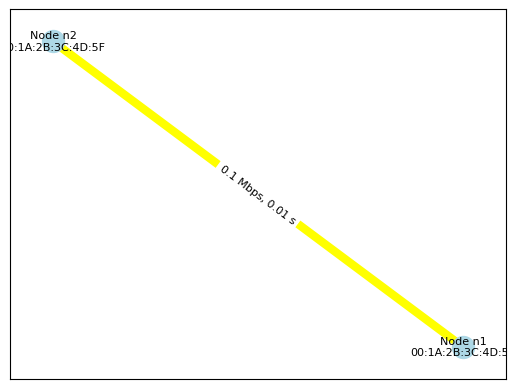

Time: 1.01 Node: n2, Event: arrived, Packet: fb78a0e6-96ac-4a4c-8e1a-7802eeffc01d, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.01 Node: n2, Event: fragment_stored, Packet: fb78a0e6-96ac-4a4c-8e1a-7802eeffc01d, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.1300000000000001 Node: n2, Event: arrived, Packet: fd3dad05-110c-4dfb-b613-56e18a65d1b2, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.1300000000000001 Node: n2, Event: fragment_stored, Packet: fd3dad05-110c-4dfb-b613-56e18a65d1b2, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.25 Node: n2, Event: arrived, Packet: b6c13d37-2473-4c80-baf6-e5c64488d878, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.25 Node: n2, Event: fragment_stored, Packet: b6c13d37-2473-4c80-baf6-e5c64488d878, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.3699999999999999 Node: n2, Event: arrived, Packet: a38e01d2-3365-45ef-91f9-7930ee7519ee, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.3699999999999999

In [ ]:
from sec5a.NetworkEventScheduler import NetworkEventScheduler
from sec5a.Node import Node
from sec5a.Link import Link

network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True, stp_verbose=False)

# ノードとスイッチの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.1", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.1.2", network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", destination_ip="192.168.1.2",bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


### 課題
1. リンクのMTUの設定を変えて、パケットのフラグメントのされ方が変わることを確認してみましょう。
2. ペイロードサイズを変えて、フラグメント数に応じて送受信バイト数が変化することを確認しましょう。


## ネットワークアドレスとサブネットマスク

### アドレスの階層性

さて、IPアドレスは導入しましたが、このままではインターネットのような規模の大きなネットワークには使えません。
IPアドレスもMACアドレスも、ネットワーク上のノードを一意に特定する識別子である、という点では同じです。
ただしIPアドレスの重要な点は、ネットマスクアドレスを用いることで階層的にアドレス情報を扱えることです。
階層的にアドレスを扱うということは、複数のノードをまとめたアドレスを使える、という意味です。

### ネットワークアドレス

ネットワークアドレスは、コンピュータネットワーク内の特定のサブネットワーク（またはセグメント）を識別するために使われるアドレスです。
つまりネットワーク上で利用可能なホストのグループを表します。
例えば、あるローカルネットワーク内で`192.168.1.1`から`192.168.1.255`の範囲のアドレスを持つノードを表すネットワークアドレスは、`192.168.1.0`です（正確には、最大値の`255`はブロードキャスト用アドレスなので、このケースではノードには`254`までしか割り当てません）。
言い方を変えれば、`192.168.1.x`というアドレスを持つホストが`192.168.1.0`のネットワークに属しています。

### サブネットマスク

サブネットマスクは、IPアドレスの中でネットワークアドレス部分とホストアドレス部分を区別するために使われる値です。
先の例であれば、上位の`192.168.1.`を表す24ビットがネットワーク部であり、下位の`1`から`255`を表す8ビットがホスト部ということになります。

IPアドレスのうち、「どこがネットワーク部か」を表す情報がサブネットマスクです。
サブネットマスクの書き方には2つの形式があります。
一つ目は、IPアドレスと同じ形式での記述です。
たとえば、サブネットマスク `255.255.255.0` は、IPアドレスの最初の3つのオクテット（8ビットごとの数値ブロック）がネットワークアドレスを表し、最後のオクテットがホストアドレスを表すことを意味します。
このサブネットマスクを `192.168.1.0` のネットワークアドレスに適用すると、`192.168.1.x` 形式のアドレスが同じネットワークに属することを意味します。

もう一つはCIDR（Classless Inter-Domain Routing）表記と呼ばれます。
IPアドレスの後ろにスラッシュ(/)と数値を付けて、ネットワークアドレスとサブネットマスクを一緒に表します。
たとえば、`192.168.1.0/24` は、ネットワークアドレス `192.168.1.0` とサブネットマスク `255.255.255.0` を組み合わせたものです。
この `/24` は、最初の24ビット（3オクテット）がネットワークアドレス部分であることを示しています。

### ネットワークアドレスとサブネットマスクの実装

本書では、IPアドレスを設定するときには、CIDR表記を用いることとします。
まず、`Node`クラスのインスタンス初期化時に、CIDR表記のIPアドレス（例えば `192.168.1.1/24`）を受け取るようにします。
そして`Node`クラスのIPアドレスのチェック関連の処理をアップデートします。

```
    def is_valid_cidr_notation(self, ip_address):
        """CIDR表記のIPアドレスが有効かどうかをチェックする関数"""
        try:
            ip_network(ip_address, strict=False)
            return True
        except ValueError:
            return False

    def receive_packet(self, packet, received_link):

        # 省略

        if packet.header["destination_mac"] == self.mac_address:
            # 宛先IPアドレスのチェック
            node_ip_address = self.ip_address.split('/')[0]
            if packet.header["destination_ip"] == node_ip_address:
                # 宛先IPがこのノードの場合
                self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
                packet.set_arrived(self.network_event_scheduler.current_time)

                # 省略
```

次に、IPアドレスの表記変更に応じて`Link`クラスをアップデートします。

```
    def __init__(self, node_x, node_y, bandwidth, delay, loss_rate, network_event_scheduler):

        # 省略

        # IPアドレスの選択とリンクの設定
        ip_x, ip_y = self.setup_link_ips(node_x, node_y)

        # リンクとIPアドレスをノードに追加
        node_x.add_link(self, ip_x)
        node_y.add_link(self, ip_y)
```

また、これから規模の大きなネットワークを模擬するため、IPアドレスの設定に関する機能を追加します。
ただし、これらはシミュレータ上の設定の簡易化が主な目的であるため、読み飛ばして問題ありません。

#### `setup_link_ips`メソッド

このメソッドは、リンクに接続された二つのノード間で互換性のあるIPアドレスを選択し設定するために使用されます。主なステップは以下の通りです。

1. **利用可能なIPアドレスリストの取得**: `get_available_ip_list`メソッドを使って、各ノード（ルータまたはノード/スイッチ）から利用可能なIPアドレスリスト（CIDR表記）を取得します。

2. **互換性のあるIPアドレスの選択**: `select_compatible_ip`メソッドを使用して、取得したIPアドレスリストから互換性のあるペアを選択します。

3. **使用済みフラグの設定**: 選択されたIPアドレスをそれぞれのノードに割り当て、使用済みとしてマークします。

```
    def setup_link_ips(self, node_x, node_y):
        # ノードから利用可能なIPアドレスリスト（CIDR表記）を取得
        ip_list_x = self.get_available_ip_list(node_x)
        ip_list_y = self.get_available_ip_list(node_y)

        # 互換性のある IP アドレスを選択
        selected_ip_x, selected_ip_y = self.select_compatible_ip(ip_list_x, ip_list_y)
        if selected_ip_x is None or selected_ip_y is None:
            raise ValueError("互換性のある IP アドレスのペアが見つかりませんでした。")

        # 使用済みIPアドレスにフラグを設定
        node_x.mark_ip_as_used(selected_ip_x)
        node_y.mark_ip_as_used(selected_ip_y)

        return selected_ip_x, selected_ip_y
```

#### `get_available_ip_list`メソッド

このメソッドは、与えられたノードタイプ（ルータまたはノード/スイッチ）に応じて利用可能なIPアドレスリストを返します。ルータの場合は、未使用のIPアドレスリストを返し、ノードやスイッチの場合は、そのノードのIPアドレスのみを含むリストを返します。

```
    def get_available_ip_list(self, node):
        # 各ノードタイプに応じて利用可能なIPアドレスリストを返す
        if isinstance(node, Router):
            return node.get_available_ip_addresses()
        else:
            return [node.ip_address]  # NodeやSwitchの場合
```

#### `select_compatible_ip`メソッド

二つのノード間で互換性のあるIPアドレスを選択するためのメソッドです。CIDR表記で提供されるIPアドレスリストから、同じネットワークに属するIPアドレスペアを見つけます。

```
    def select_compatible_ip(self, ip_list_x, ip_list_y):
        # CIDR表記で提供されるIPアドレスリストから互換性のあるIPアドレスを選択
        for ip_cidr_x in ip_list_x:
            for ip_cidr_y in ip_list_y:
                if self.is_compatible(ip_cidr_x, ip_cidr_y):
                    return ip_cidr_x, ip_cidr_y
        return None, None  # 互換性のあるアドレスが見つからない場合
```

#### `is_compatible`メソッド

二つのIPアドレスが同じネットワークに属するかどうかを判断するメソッドです。CIDR表記からIPアドレスとサブネットマスクを抽出し、整数に変換してネットワークアドレスを計算します。両方のネットワークアドレスが同じ場合、同じネットワークに属していると判断されます。

```
    def is_compatible(self, ip_cidr_x, ip_cidr_y):
        """
        二つのIPアドレス（CIDR表記）が同じネットワークに属しているかどうかを判断する。
        :param ip_cidr_x: ノードXのIPアドレス（CIDR表記）
        :param ip_cidr_y: ノードYのIPアドレス（CIDR表記）
        :return: 同じネットワークに属している場合はTrue、そうでない場合はFalse
        """
        ip_address_x, subnet_mask_x = ip_cidr_x.split('/')
        ip_address_y, subnet_mask_y = ip_cidr_y.split('/')

        # CIDR表記のサブネットマスクを整数に変換
        mask_int_x = self.subnet_mask_to_int(subnet_mask_x)
        mask_int_y = self.subnet_mask_to_int(subnet_mask_y)

        # ネットワークアドレスの計算
        network_x = self.ip_to_int(ip_address_x) & mask_int_x
        network_y = self.ip_to_int(ip_address_y) & mask_int_y

        # ネットワークアドレスが一致する場合、同じネットワークに属していると判断
        return network_x == network_y
```

#### `get_network_address`メソッド

IPアドレスとサブネットマスクからネットワークアドレスを計算するメソッドです。ビット演算を用いて、与えられたIPアドレスのネットワーク部分を抽出します。

```
    def get_network_address(self, ip_address, subnet_mask):
        """
        IPアドレスとサブネットマスクからネットワークアドレスを計算する。

        :param ip_address: 計算するIPアドレス
        :param subnet_mask: 使用するサブネットマスク
        :return: ネットワークアドレス
        """
        # IPアドレスとサブネットマスクをビット演算できるように整数に変換
        ip_addr_int = self.ip_to_int(ip_address)
        mask_int = self.ip_to_int(subnet_mask)

        # ネットワークアドレスの計算
        return ip_addr_int & mask_int
```

#### `ip_to_int`メソッド

IPアドレスを整数に変換するメソッドです。これにより、IPアドレスのビット演算が可能になります。

```
    def ip_to_int(self, ip_address):
        """
        IPアドレスを整数に変換する。

        :param ip_address: 変換するIPアドレス
        :return: 対応する整数
        """
        octets = ip_address.split('.')
        return sum(int(octet) << (8 * i) for i, octet in enumerate(reversed(octets)))
```

#### `subnet_mask_to_int`メソッド

CIDR表記のサブネットマスクを整数に変換するメソッドです。これにより、サブネットマスクを使ったビット演算が可能になります。

```
    def subnet_mask_to_int(self, subnet_mask):
        """
        サブネットマスク（CIDR表記）を整数に変換する。
        :param subnet_mask: サブネットマスク（例: "24"）
        :return: 対応する整数
        """
        return (0xffffffff >> (32 - int(subnet_mask))) << (32 - int(subnet_mask))
```


## ルータ

### コンピュータネットワークにおけるルータ

いよいよ、インターネットのような大きなネットワークにおいてパケットを中継する、ルータを導入していきます。
コンピュータネットワークにおいて、ルータは非常に重要な役割を果たします。
ルータは、異なるネットワーク間でデータを転送するデバイスで、ネットワークのトラフィックを効率的に管理し、異なるネットワーク間の通信を可能にします。
前章で出てきたスイッチは、ローカルネットワーク内でのパケット中継を担う装置でした。
これに対してルータは、異なるローカルネットワーク同士を接続し、それらの間でデータを転送します。例えば、家庭内のネットワークとインターネットを接続する役割を果たします。

ルータにはさまざまな種類があります。一般的な家庭用ルータから、大企業やISP（インターネットサービスプロバイダ）が使用する高性能なルータまで、その規模と機能は多岐にわたります。家庭用ルータは、通常、無線LAN機能（Wi-Fi）を備え、複数のデバイスをインターネットに接続するために使用されます。

ルータの機能の中でも重要なものが、ルーティングです。
ルーティングは、データパケットが送信元から目的地まで最適な経路を通って転送されるプロセスです。
ルータは、ルーティングテーブルと呼ばれる情報を利用して、パケットが次に進むべき方向を決定します。
その結果として、パケットは複数のルータを経由して目的地に効率良く到達します。

### ルーティングテーブル

ルーティングテーブルは、ルータがデータパケットを送るべき最適な経路を決定するための情報が記載されたリストです。
このテーブルには、目的地のネットワークアドレス、その目的地への最適なルートを通るための「次のホップ」（次にデータを送るべきルータまたはデバイス）のアドレスが含まれています。

ルータは受け取ったデータパケットの宛先IPアドレスを見て、自身のルーティングテーブルを参照します。
そこには、そのデータパケットを送るべき「次のホップ」が記載されています。
ルータはこの情報に基づいて、パケットを次の目的地（次のホップ）へと転送します。

### `Router`クラスの設計方針

Routerクラスは、ネットワーク内のルータをシミュレートするために設計されています。このクラスは、ルーティングテーブルの管理、IPアドレスの割り当て、パケットの転送といったルータの基本的な機能を模擬します。
ルーティングテーブルや、テーブルを参照した転送先リンク選択など、基本的な機能を含んでいます。
ただし、現段階ではまだルーティングテーブルは手動で設定するようになっています。

#### 初期化メソッド `__init__`
- `node_id`, `ip_addresses`, `network_event_scheduler` というパラメータを受け取ります。
- `node_id` はルータの識別子で、ネットワーク内でのルータを特定するために使用されます。
- `ip_addresses` はルータに割り当てるIPアドレスのリストです。後で詳しく扱いますが、ルータはリンク（インタフェース）ごとに異なるIPアドレスを持ち、ネットワーク同士を接続します。
- `network_event_scheduler` はネットワークイベントを管理するための外部オブジェクトで、ルータの動作をネットワーク全体と同期させるために使用されます。
- ルータは、使用可能なIPアドレスを管理し、ルーティングテーブルを保持し、ネットワークイベントスケジューラに自身を登録します。

```
class Router:
    def __init__(self, node_id, ip_addresses, network_event_scheduler):
        # ルータの初期化
        # node_id: ルータのID
        # ip_addresses: このルータが使用可能なIPアドレスのリスト
        # network_event_scheduler: ネットワークイベントを管理するスケジューラ
        self.network_event_scheduler = network_event_scheduler
        self.node_id = node_id
        self.links = []  # このルータに接続されているリンクのリスト
        # CIDR表記のIPアドレスを辞書に変換し、使用状況をFalse（未使用）に初期化
        self.available_ips = {ip: False for ip in ip_addresses}
        self.interfaces = {}  # インターフェース（リンクとIPアドレスのマッピング）
        self.routing_table = {}  # ルーティングテーブル
        label = f'Router {node_id}'
        self.network_event_scheduler.add_node(node_id, label)
```

#### リンクの追加 `add_link`
- ルータに新しいリンクを追加します。リンクは、他のルータやデバイスへの接続を表します。

```
    def add_link(self, link, ip_address=None):
        # リンクをルータのインターフェースリストに追加するメソッド
        # link: 接続するリンク
        # ip_address: そのリンクに割り当てるIPアドレス（オプション）
        if link not in self.interfaces:
            self.interfaces[link] = ip_address
```

#### IPアドレスの管理 `mark_ip_as_used`, `get_available_ip_addresses`
- IPアドレスの使用状況を管理し、使用可能なIPアドレスを追跡します。これはシミュレータ上での設定を簡易化するために用いられます。

```
    def mark_ip_as_used(self, ip_address):
        # 指定されたIPアドレスを使用済みにマークするメソッド
        # ip_address: 使用済みにするIPアドレス
        if ip_address in self.available_ips:
            self.available_ips[ip_address] = True  # 辞書の値をTrue（使用済み）に更新
        else:
            raise ValueError(f"IPアドレス {ip_address} はこのルータに存在しません。")

    def get_available_ip_addresses(self):
        # 利用可能な（未使用の）IPアドレスリストを返すメソッド
        return [ip for ip in self.available_ips if ip not in self.interfaces.values()]
```

#### ルーティングテーブルの管理 `add_route`, `get_route`
- 宛先に最適なルート（次のホップと使用するリンク）をルーティングテーブルに追加、検索します。

```
    def add_route(self, destination_cidr, next_hop, link):
        # ルーティングテーブルにルートを追加するメソッド
        # destination_cidr: 宛先ネットワークのCIDR表記
        # next_hop: 次のホップのアドレス
        # link: 使用するリンク
        self.routing_table[destination_cidr] = (next_hop, link)

    def get_route(self, destination_ip):
        """
        CIDR形式のルーティングテーブルから宛先IPアドレスに最適なルートを検索する。
        :param destination_ip: 宛先のIPアドレス
        :return: 最適な次のホップと使用するリンクのタプル。ルートが見つからない場合は(None, None)を返す。
        """
        for network_cidr, (next_hop, link) in self.routing_table.items():
            network_address, mask_length = network_cidr.split('/')
            subnet_mask = self.cidr_to_subnet_mask(mask_length)

            if self.matches_subnet(destination_ip, network_address, subnet_mask):
                return next_hop, link
        return None, None
```

#### パケットの転送 `forward_packet`, `receive_packet`
- パケットが受信されると、その宛先に基づいて適切なリンクにパケットを転送します。
- `forward_packet` は、ルーティングテーブルに基づいてパケットを次のホップに転送します。
- `receive_packet` は、受信したパケットを適切なインターフェースで処理し、必要に応じて転送します。

```
    def forward_packet(self, packet):
        # パケットを適切なリンクへ転送するメソッド
        # packet: 転送するパケット
        destination_ip = packet.header["destination_ip"]
        next_hop, link = self.get_route(destination_ip)

        if link:
            # ルートが見つかった場合、パケットを転送する
            self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
            link.enqueue_packet(packet, self)
        elif self.default_route:
            # デフォルトルートが設定されている場合、そのルートを使用して転送する
            self.network_event_scheduler.log_packet_info(packet, "forwarded via default route", self.node_id)
            self.default_route.enqueue_packet(packet, self)
        else:
            # ルートが見つからず、デフォルトルートもない場合、パケットをドロップする
            self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)

    def receive_packet(self, packet, received_link):
        """
        ルータがパケットを受け取るときに呼ばれる。適切なインターフェースを見つけ、パケットを処理する。
        :param packet: 処理するパケット
        :param received_link: パケットを受信したリンク
        """
        destination_ip = packet.header["destination_ip"]
        for link, interface_cidr in self.interfaces.items():
            network_address, mask_length = interface_cidr.split('/')
            subnet_mask = self.cidr_to_subnet_mask(mask_length)
            if self.matches_subnet(destination_ip, network_address, subnet_mask):
                if self.is_final_destination(packet, network_address):
                    # パケットがこのルータ宛ての場合
                    self.process_packet(packet, received_link)
                else:
                    # そうでなければ、パケットを転送
                    self.forward_packet(packet)
                return
        # パケットがインターフェースのいずれにもマッチしない場合は転送
        self.forward_packet(packet)
```

#### ユーティリティメソッド
- IPアドレスやサブネットマスクを整数に変換するためのメソッド（`ip_to_int`, `subnet_mask_to_int`, `cidr_mask_to_int`, `cidr_to_subnet_mask`）が含まれています。

```
    def matches_subnet(self, ip_address, network_address, subnet_mask):
        # 与えられたIPアドレスが特定のサブネットに属するかを判断するメソッド
        # ip_address: 確認するIPアドレス
        # network_address: ネットワークのアドレス
        # subnet_mask: サブネットマスク
        # IPアドレスとサブネットマスクをビット演算できるように整数に変換
        ip_addr_int = self.ip_to_int(ip_address)
        network_int = self.ip_to_int(network_address)
        mask_int = self.ip_to_int(subnet_mask)

        # ネットワークアドレスの計算
        network_subnet = network_int & mask_int

        # 与えられたIPアドレスのネットワーク部を同様に抽出し、比較
        return ip_addr_int & mask_int == network_subnet

    def cidr_to_network_address(self, cidr):
        """
        CIDR表記からネットワークアドレスとサブネットマスクを計算する。
        :param cidr: CIDR表記（例: "192.168.0.1/24"）
        :return: ネットワークアドレスとサブネットマスクのタプル
        """
        network, mask_length = cidr.split('/')
        subnet_mask = self.cidr_mask_to_int(mask_length)
        return network, subnet_mask

    def is_final_destination(self, packet, network_address):
        """
        パケットがこのルータが最終宛先であるかどうかを判断する。
        :param packet: 判断するパケット
        :param network_address: ルータのネットワークアドレス
        :return: パケットが最終宛先である場合はTrue、そうでない場合はFalse
        """
        return packet.header["destination_ip"] == network_address

    def process_packet(self, packet, received_link):
        """
        パケットがこのルータ宛ての場合に実行する処理。
        例えば、ログに記録する、特定の処理を行うなど。
        :param packet: 処理するパケット
        :param received_link: パケットを受信したリンク
        """
        print(f"Packet {packet.id} processed at router {self.node_id}")

    def ip_to_int(self, ip_address):
        """
        IPアドレスを整数に変換する。
        :param ip_address: 変換するIPアドレス（文字列）
        :return: 対応する整数
        """
        octets = ip_address.split('.')
        return sum(int(octet) << (8 * i) for i, octet in enumerate(reversed(octets)))

    def subnet_mask_to_int(self, subnet_mask):
        """
        サブネットマスク（CIDR表記）を整数に変換する。
        :param subnet_mask: サブネットマスク（例: "24"）
        :return: 対応する整数
        """
        return (0xffffffff >> (32 - int(subnet_mask))) << (32 - int(subnet_mask))

    def cidr_mask_to_int(self, mask_length):
        """
        CIDR形式のサブネットマスクの長さを整数値のサブネットマスクに変換する。
        :param mask_length: CIDRマスクの長さ（例: "24"）
        :return: 対応する整数値のサブネットマスク
        """
        mask_length = int(mask_length)
        mask = (1 << 32) - (1 << (32 - mask_length))
        return mask

    def cidr_to_subnet_mask(self, mask_length):
        """
        CIDRマスク長からサブネットマスクを計算する。
        :param mask_length: CIDRマスクの長さ（例: "24"）
        :return: 対応するサブネットマスクの文字列
        """
        mask_length = int(mask_length)
        mask = (0xffffffff >> (32 - mask_length)) << (32 - mask_length)
        return f"{(mask >> 24) & 0xff}.{(mask >> 16) & 0xff}.{(mask >> 8) & 0xff}.{mask & 0xff}"
```


### ルータによるパケット転送のテスト

作成した`Router`クラスを用いて、パケット転送のテストをしてみましょう。
以下のサンプルでは2つの`Node`を2つの`Router`を介して接続し、パケットの送受信を行ってみます。


このシナリオは、簡素化されたネットワーク環境での通信プロセスをシミュレートするものです。具体的には、二つのノードと二つのルータを使ってパケットの送受信を行う過程を表現しています。以下は、このシミュレーションシナリオの各部分についての解説です。
ここまでの復習も交えて、各要素について解説します。

#### NetworkEventScheduler
- ネットワークのイベント（パケットの送受信、リンクの変化など）を管理し、シミュレーション全体をコントロールする役割を果たします。
- `log_enabled` と `verbose` オプションにより、イベントの記録と詳細なログの出力が可能です。

#### Node（ノード）
- 通信を行う端末を表します。このシナリオでは `node1` と `node2` の2つのノードがあります。
- 各ノードには固有のMACアドレスとIPアドレスが割り当てられています。

#### Router（ルータ）
- ネットワーク上でパケットを転送する役割を持ちます。`router1` と `router2` がそれぞれ設定されています。
- ルータは複数のIPアドレス（異なるネットワークセグメントへのインターフェース）を持っています。

#### Link（リンク）
- ノードとルータ、ルータ同士を物理的に接続します。
- リンクの特性として、帯域幅（bandwidth）、遅延（delay）、パケット損失率（loss_rate）が設定されます。

#### ルーティングテーブルの設定
- ルータ1とルータ2のルーティングテーブルが設定されており、どのルートを通じて異なるネットワークセグメントへのパケットを転送すべきかを定義しています。

### シミュレーションのプロセス

1. **ネットワークの設定**: 上述の構成要素を用いてネットワークが構築されます。
2. **トポロジの描画**: `network_event_scheduler.draw()` により、ネットワークのトポロジ（ノードとリンクの配置）が視覚化されます。
3. **通信アプリケーションの設定**: `node1` から `node2` へのデータトラフィックが設定されます。このトラフィックは、特定のビットレート、開始時刻、持続時間で定義されています。
4. **イベントスケジューラの実行**: `network_event_scheduler.run()` により、設定されたトラフィックに基づいてパケットの送受信が行われ、ネットワーク上でのイベントが進行します。
5. **結果の確認**: シミュレーション終了後、パケットログを用いてネットワークのパフォーマンス（スループットや遅延など）の分析が行われます。


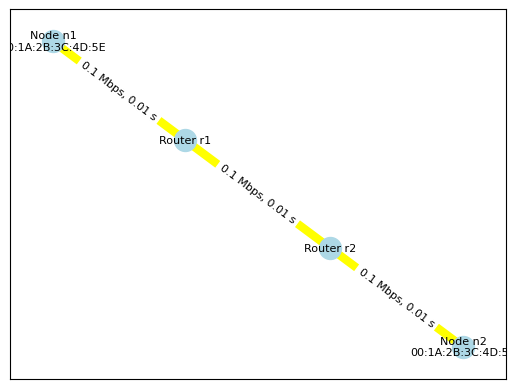

Time: 1.01 Node: r1, Event: forwarded, Packet: b1b0298c-5c72-41f9-a673-60adf59181b2, Src: 192.168.1.1, Dst: 192.168.2.1
Time: 1.02 Node: r2, Event: forwarded, Packet: b1b0298c-5c72-41f9-a673-60adf59181b2, Src: 192.168.1.1, Dst: 192.168.2.1
Time: 1.03 Node: n2, Event: arrived, Packet: b1b0298c-5c72-41f9-a673-60adf59181b2, Src: 192.168.1.1, Dst: 192.168.2.1
Time: 1.03 Node: n2, Event: fragment_stored, Packet: b1b0298c-5c72-41f9-a673-60adf59181b2, Src: 192.168.1.1, Dst: 192.168.2.1
Time: 1.1300000000000001 Node: r1, Event: forwarded, Packet: 9408f3bb-eeaa-46f8-a901-7da4ae173c10, Src: 192.168.1.1, Dst: 192.168.2.1
Time: 1.1400000000000001 Node: r2, Event: forwarded, Packet: 9408f3bb-eeaa-46f8-a901-7da4ae173c10, Src: 192.168.1.1, Dst: 192.168.2.1
Time: 1.1500000000000001 Node: n2, Event: arrived, Packet: 9408f3bb-eeaa-46f8-a901-7da4ae173c10, Src: 192.168.1.1, Dst: 192.168.2.1
Time: 1.1500000000000001 Node: n2, Event: fragment_stored, Packet: 9408f3bb-eeaa-46f8-a901-7da4ae173c10, Src: 192.16

In [ ]:
from sec5b.NetworkEventScheduler import NetworkEventScheduler
from sec5b.Node import Node
from sec5b.Router import Router
from sec5b.Link import Link

network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True, stp_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.1.1/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.2.1/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.0.0.1/24"], network_event_scheduler=network_event_scheduler)
router2 = Router(node_id="r2", ip_addresses=["10.0.0.2/24", "192.168.2.254/24"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(router1, router2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(router2, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ルーティングテーブルの設定
# ルータ1のルーティングテーブルに直接接続されているネットワークへのルートを追加
router1.add_route("192.168.1.0/24", None, link1)  # node1への直接ルート
router1.add_route("192.168.2.0/24", "10.0.0.2", link2)  # router2へのルート

# ルータ2のルーティングテーブルに直接接続されているネットワークへのルートを追加
router2.add_route("192.168.2.0/24", None, link3)  # node2への直接ルート
router2.add_route("192.168.1.0/24", "10.0.0.1", link2)  # router1へのルート

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", destination_ip="192.168.2.1", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


### 演習課題1: ネットワーク設定の誤りの特定と修正

#### 目的
与えられたネットワーク設定に含まれる誤りを見つけ、適切に修正することで、IPアドレッシングとサブネットマスクの基本原則を理解する。

#### 課題
次のネットワーク設定には誤りが含まれています。誤りを見つけて修正しましょう。
ノードとルータのIPアドレス設定に注目し、それらが同じネットワーク内にあるかどうかを確認します。また、ルータのインターフェイスが異なるネットワークに対応しているかを検討する必要があります。

```python
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", ip_address="192.168.10.10/24", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", ip_address="192.168.20.10/24", network_event_scheduler=network_event_scheduler)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(router1, node2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
```

### 演習課題2: ルーティングテーブルの設定

#### 目的
ルータにルーティングテーブルを設定し、IPネットワーク間でのパケット転送の仕組みを理解する。

#### 課題
問1で修正したネットワーク設定に基づいて、ルータ `r1` のルーティングテーブルを設定し、ノード `n1` から `n2` へのパケット転送を実行してみましょう。

### 演習課題3: パケット送受信の実践

#### 目的
ルーティングテーブルを設定したルータを使用して、実際にノード間でパケット送受信を行い、IPネットワークでの通信の仕組みを体験する。

#### 課題
ルータ `r1` にルーティングテーブルを設定した後、ノード `n1` から `n2` へパケットを送信し、正しく通信が行われるかを確認しましょう。


## 本章のまとめ

本章では、インターネット上でのパケット転送の中核を担うIPアドレスとルータを実装しました。
IPアドレスとルーティングテーブルを用いたパケット転送と、大きなデータに対するフラグメントと再組立ての処理も作成しました。
またネットワークアドレスとサブネットマスクについても学習し、ネットワーク間での通信を模擬してみました。
少し盛りだくさんではありましたが、これまでに学習したMACアドレスとスイッチを用いたパケット中継と似ている部分もあるため、アナロジーとして理解するのも良いかと思います。
さて、本章ではルーティングテーブルを手書きしていましたが、実際には膨大な数のIPアドレスをすべて書くのは不可能です。
次章では、動的なルーティングを行うためのルーティングプロトコルについて学びます。
